# Predictive Maintenance for Industrial Equipment Failure

## Exploratory Data Analysis (EDA) and Model Evaluation

**Project Type:** Binary Classification  
**Dataset:** Predictive Maintenance Dataset  
**Prepared by:** Amna Bibi  
**Team:** Baby Seven  
**Role:** Exploratory Data Analysis & Model Evaluation

---

### Project Objective

The objective of this project is to develop a predictive maintenance system that can identify whether an industrial equipment observation is associated with a machine failure.

The project follows a data science workflow consisting of:

1. Data loading and understanding
2. Data quality assessment
3. Exploratory Data Analysis (EDA)
4. Data preprocessing
5. Feature engineering
6. Machine learning classification
7. Model evaluation
8. Dashboard and deployment

This notebook focuses primarily on **Exploratory Data Analysis and Model Evaluation**.

## 1. Importing Required Libraries

The following Python libraries are used for data manipulation, numerical analysis, visualization, and statistical exploration.

- **Pandas:** Data loading, manipulation, and analysis
- **NumPy:** Numerical computations
- **Matplotlib:** Data visualization
- **Seaborn:** Statistical visualization
- **Warnings:** Suppression of non-critical warnings

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading the Dataset

The cleaned predictive maintenance dataset prepared by the project team is loaded for exploratory analysis.

The dataset contains time information, equipment/device identifiers, a binary failure indicator, and multiple sensor measurements.

The target variable for the classification problem is:

- `failure = 0`: No failure
- `failure = 1`: Failure

In [5]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current working directory:
c:\Users\khan\Desktop\house price prediction\Predictive-Maintenance-for-Industrial-Equipment-Failure-Classification-\notebooks

Files/folders here:
['eda.ipynb']


In [6]:
print("Parent folder:")
print(os.listdir(".."))

Parent folder:
['.git', '.gitignore', '.venv', 'cleaned_predictive_maintenance_dataset.csv', 'main.py', 'notebooks']


In [8]:
df = pd.read_csv("../cleaned_predictive_maintenance_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (66330, 12)


,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
0,1/1/2015,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0
1,1/1/2015,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0
2,1/1/2015,S1F01XDJ,0,227721632,0,0,0,8,402525,0,0,0
3,1/1/2015,S1F0322R,0,34540712,0,0,0,9,411399,0,0,0
4,1/1/2015,S1F035SJ,0,220392160,0,0,0,9,389730,0,0,0


## 3. Dataset Overview

Before performing statistical analysis, it is important to understand the structure and dimensions of the dataset.

The following analysis examines:

- Number of observations
- Number of variables
- Variable names
- Data types
- Initial records
- Summary statistics

Understanding the dataset structure helps identify suitable preprocessing and analysis techniques.

In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 66330
Number of columns: 12

Column names:
['date', 'device', 'failure', 'metric1', 'metric2', 'metric3', 'metric4', 'metric5', 'metric6', 'metric7', 'metric8', 'metric9']


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66330 entries, 0 to 66329
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   date     66330 non-null  str  
 1   device   66330 non-null  str  
 2   failure  66330 non-null  int64
 3   metric1  66330 non-null  int64
 4   metric2  66330 non-null  int64
 5   metric3  66330 non-null  int64
 6   metric4  66330 non-null  int64
 7   metric5  66330 non-null  int64
 8   metric6  66330 non-null  int64
 9   metric7  66330 non-null  int64
 10  metric8  66330 non-null  int64
 11  metric9  66330 non-null  int64
dtypes: int64(10), str(2)
memory usage: 6.1 MB


In [11]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,66330,304,1/1/2015,621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device,66330,622,S1F0FGBQ,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
failure,66330.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
metric1,66330.0,NaN,NaN,NaN,122549251.768913,70482878.883469,0.0,61302250.0,123368076.0,183614704.0,244133240.0
metric2,66330.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
metric3,66330.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
metric4,66330.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
metric5,66330.0,NaN,NaN,NaN,9.447022,2.759663,2.0,8.0,9.0,11.0,18.0
metric6,66330.0,NaN,NaN,NaN,266461.610749,56628.937796,88840.0,223423.25,249778.0,301587.25,448235.0
metric7,66330.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Data Types

Examining data types is an important preprocessing and EDA step.

Numerical variables can be analyzed using statistical measures and numerical visualizations, while categorical variables require different analytical techniques.

The `date` variable will be converted into a datetime format to enable time-based analysis.

In [12]:
df.dtypes

date         str
device       str
failure    int64
metric1    int64
metric2    int64
metric3    int64
metric4    int64
metric5    int64
metric6    int64
metric7    int64
metric8    int64
metric9    int64
dtype: object

## 5. Date and Time Processing

The dataset contains a `date` variable representing the observation date.

Converting this variable to datetime format allows us to investigate temporal patterns in equipment failures, including failure frequency over time.

In [13]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Date conversion completed.")
print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())

Date conversion completed.
Minimum date: 2015-01-01 00:00:00
Maximum date: 2015-11-02 00:00:00


## 6. Missing Value Analysis

Missing values can affect statistical analysis and machine learning performance.

The number and percentage of missing observations are therefore examined for each variable.

If missing values are present, their treatment should be documented in the preprocessing stage.

In [14]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing)

,Missing Count,Missing Percentage
date,0,0.0
device,0,0.0
failure,0,0.0
metric1,0,0.0
metric2,0,0.0
metric3,0,0.0
metric4,0,0.0
metric5,0,0.0
metric6,0,0.0
metric7,0,0.0


## 7. Duplicate Record Analysis

Duplicate observations may bias statistical analysis and machine learning models.

The dataset is checked for completely duplicated rows.

In [15]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 8. Unique Value Analysis

The number of unique values in each variable is examined to understand the nature of the dataset and identify identifier-like variables or variables with limited categories.

In [16]:
unique_values = df.nunique().sort_values()

display(unique_values)

failure        1
metric2        1
metric3        1
metric4        1
metric7        1
metric8        1
metric9        1
metric5       17
date         304
device       622
metric6    26855
metric1    66107
dtype: int64

## 9. Target Variable Analysis

The target variable is `failure`, which represents whether an equipment failure occurred.

- `0` represents no failure.
- `1` represents failure.

Understanding the target distribution is essential because an imbalanced target can strongly affect classification model performance.

If failure observations are substantially fewer than non-failure observations, accuracy alone will not be a reliable measure of model performance.

In [17]:
failure_percent = (
    df["failure"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(failure_percent)

failure
0    100.0
Name: proportion, dtype: float64

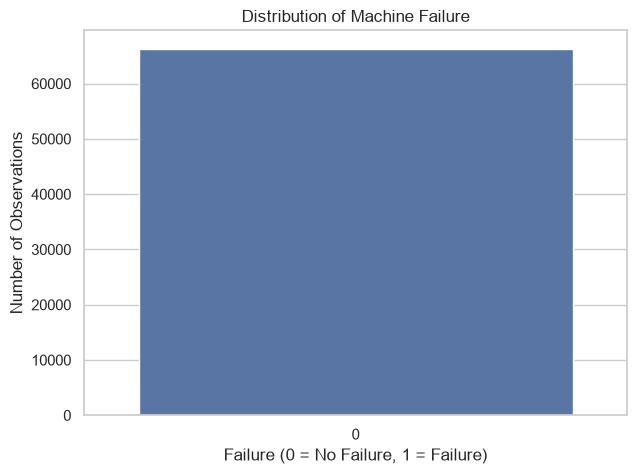

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="failure")

plt.title("Distribution of Machine Failure")
plt.xlabel("Failure (0 = No Failure, 1 = Failure)")
plt.ylabel("Number of Observations")

plt.show()

### Interpretation

The target distribution shows the relative frequency of failure and non-failure observations.

A substantial difference between the two classes indicates class imbalance. This is particularly important for predictive maintenance because a model that predicts the majority class most of the time can achieve high accuracy while failing to detect actual equipment failures.

Therefore, model evaluation should emphasize metrics such as **precision, recall, F1-score, ROC-AUC, and particularly PR-AUC**, rather than relying on accuracy alone.

## 10. Numerical Feature Analysis

The sensor variables are examined using descriptive statistics and visualizations.

The analysis focuses on:

- Central tendency
- Dispersion
- Distribution shape
- Potential extreme observations

These characteristics help us understand the operating conditions represented in the dataset.

In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical variables:")
print(numeric_cols)

Numerical variables:
['failure', 'metric1', 'metric2', 'metric3', 'metric4', 'metric5', 'metric6', 'metric7', 'metric8', 'metric9']


## 11. Descriptive Statistics

Descriptive statistics provide an overview of the numerical variables.

The mean and median describe central tendency, while standard deviation, minimum, and maximum values provide information about variability and range.

In [20]:
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
failure,66330.0,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.000000e+00,0.0
metric1,66330.0,1.225493e+08,7.048288e+07,0.0,61302250.00,123368076.0,1.836147e+08,244133240.0
metric2,66330.0,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.000000e+00,0.0
metric3,66330.0,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.000000e+00,0.0
metric4,66330.0,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.000000e+00,0.0
metric5,66330.0,9.447022e+00,2.759663e+00,2.0,8.00,9.0,1.100000e+01,18.0
metric6,66330.0,2.664616e+05,5.662894e+04,88840.0,223423.25,249778.0,3.015872e+05,448235.0
metric7,66330.0,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.000000e+00,0.0
metric8,66330.0,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.000000e+00,0.0
metric9,66330.0,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.000000e+00,0.0


## 12. Distribution of Sensor Metrics

Histograms are used to examine the distributions of the available sensor measurements.

Understanding these distributions can reveal skewness, concentration of values, and unusual observations that may require further investigation.

In [21]:
metric_cols = [col for col in df.columns if col.startswith("metric")]

print("Sensor metrics:")
print(metric_cols)

Sensor metrics:
['metric1', 'metric2', 'metric3', 'metric4', 'metric5', 'metric6', 'metric7', 'metric8', 'metric9']


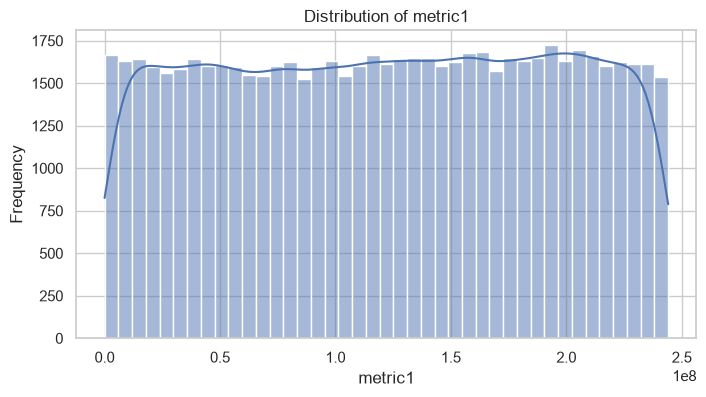

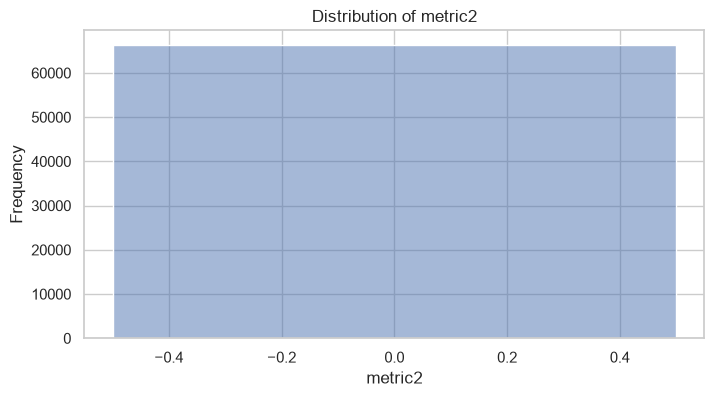

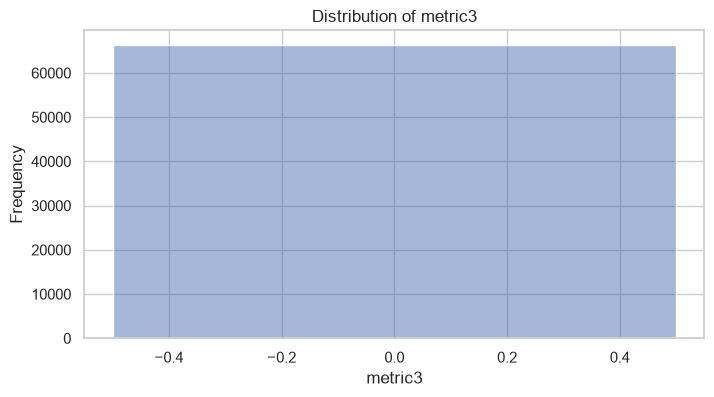

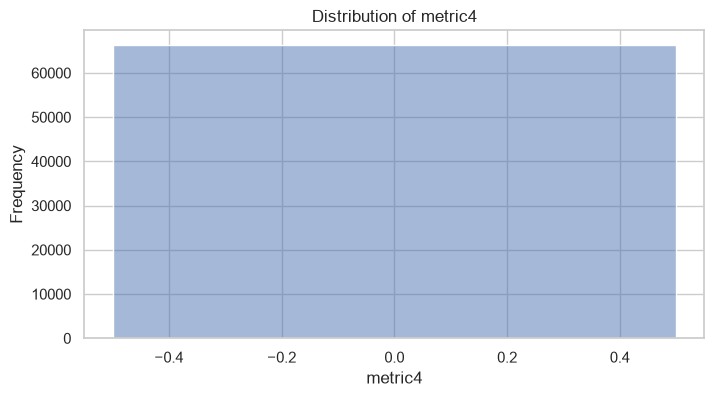

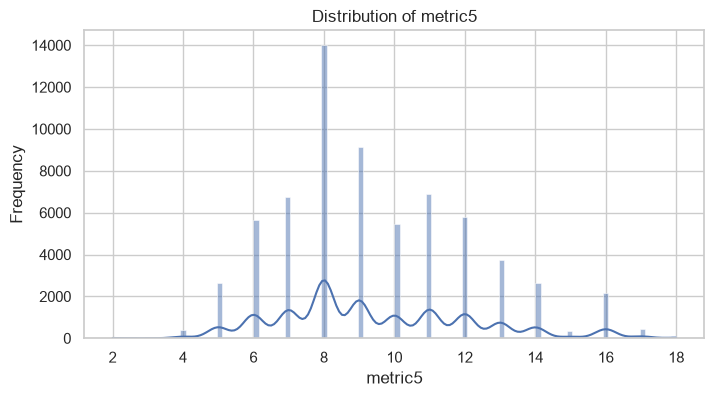

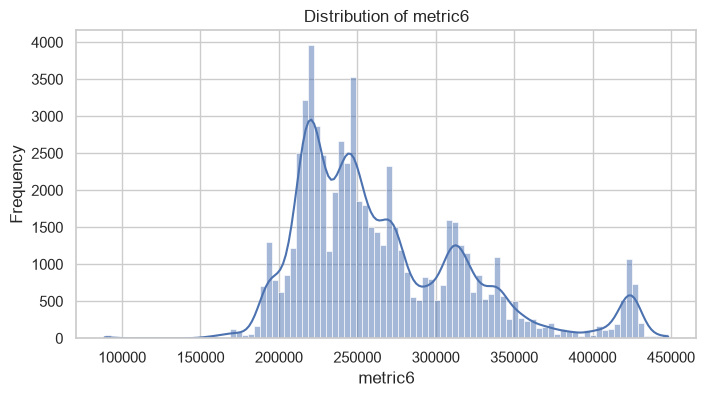

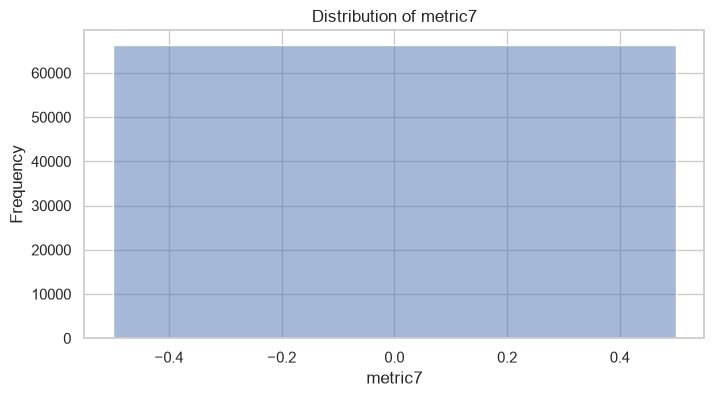

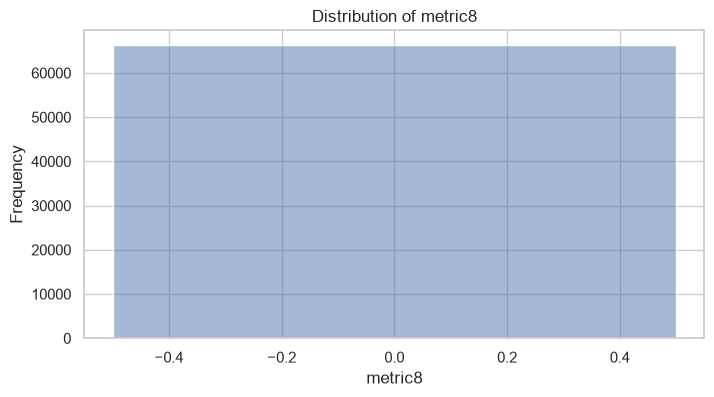

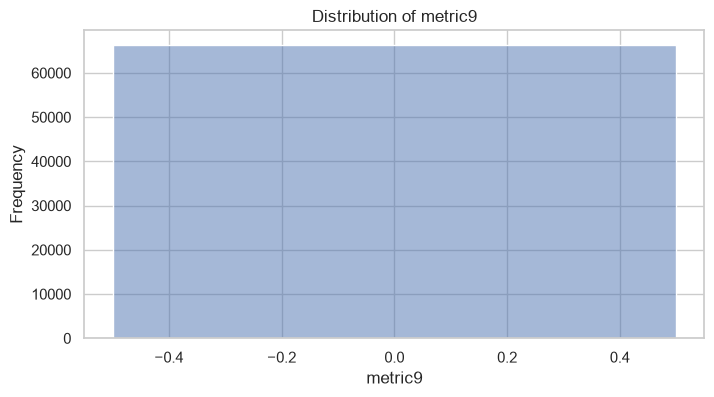

In [22]:
for col in metric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## 13. Outlier Analysis

Boxplots are used to identify observations that fall substantially outside the central range of each sensor metric.

An identified outlier is not automatically considered an error. In industrial datasets, extreme sensor readings may represent genuine operating conditions.

Therefore, potential outliers should be interpreted in the context of the equipment and measurement process rather than removed automatically.

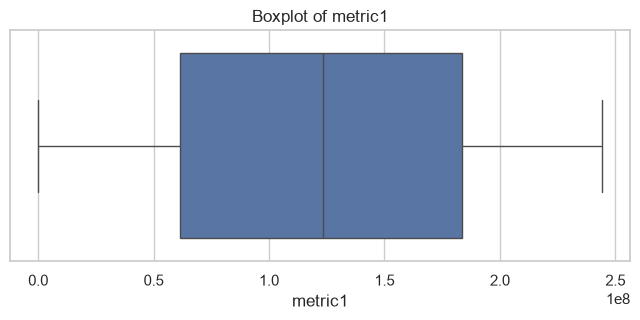

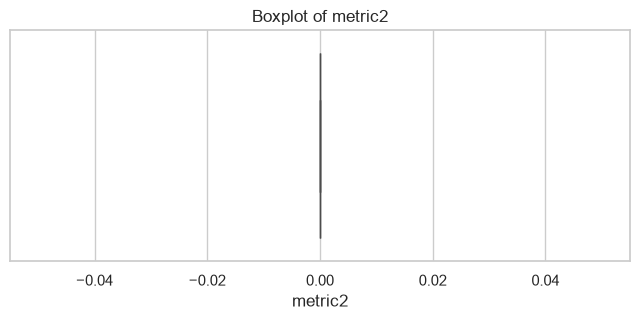

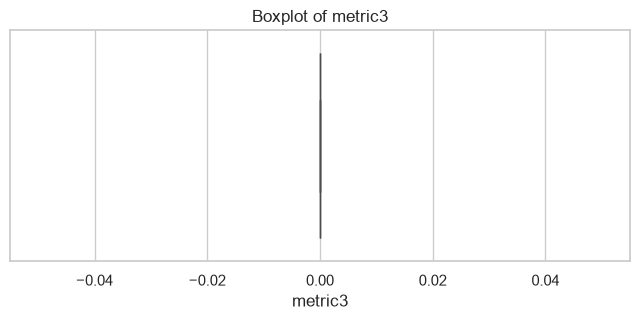

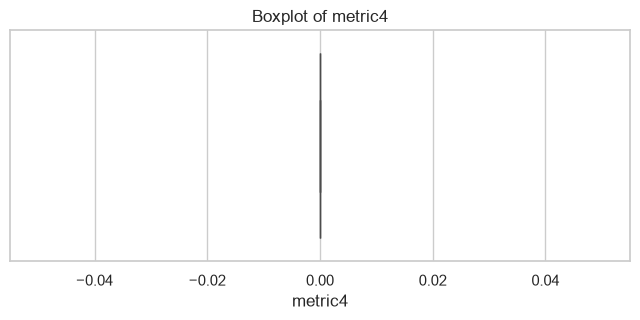

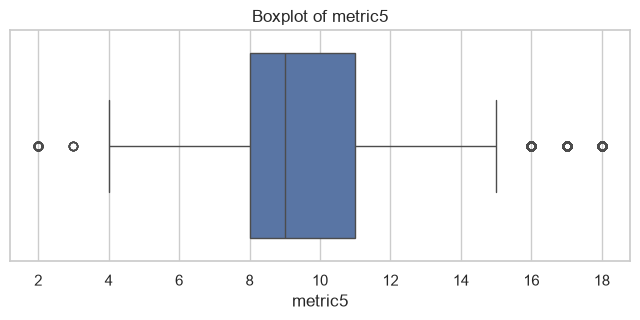

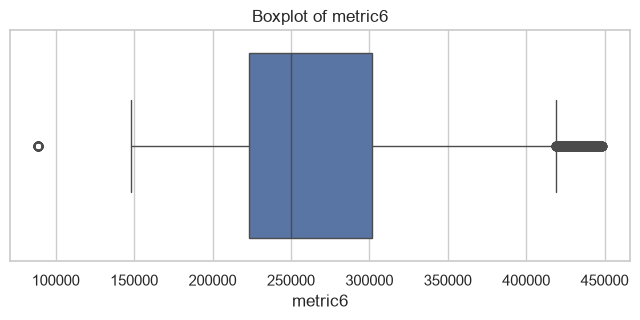

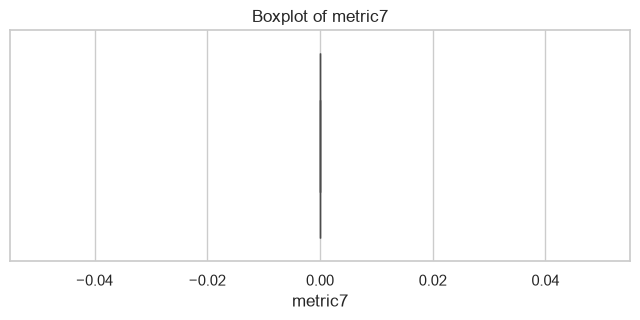

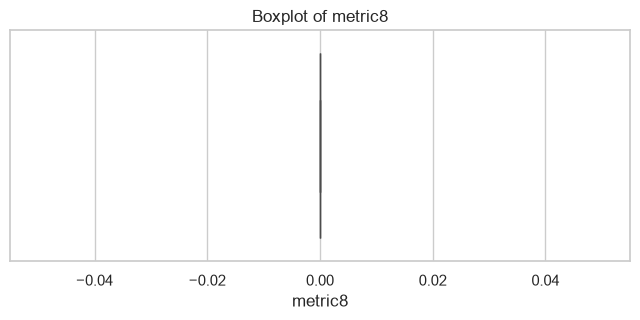

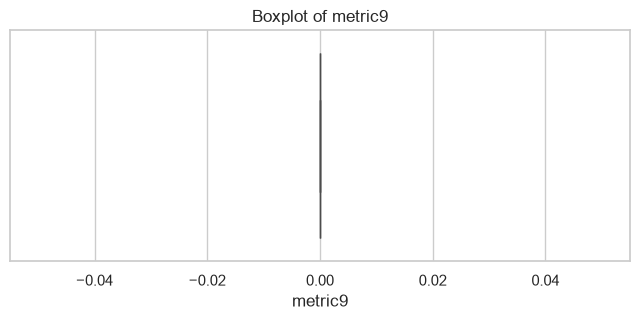

In [23]:
for col in metric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

## 14. Sensor Metrics by Machine Failure Status

To identify potential relationships between sensor measurements and equipment failure, each sensor metric is compared between the two target classes.

Boxplots allow comparison of the distribution of sensor measurements for:

- Non-failure observations (`failure = 0`)
- Failure observations (`failure = 1`)

Differences between the two groups may indicate potentially useful predictive features.

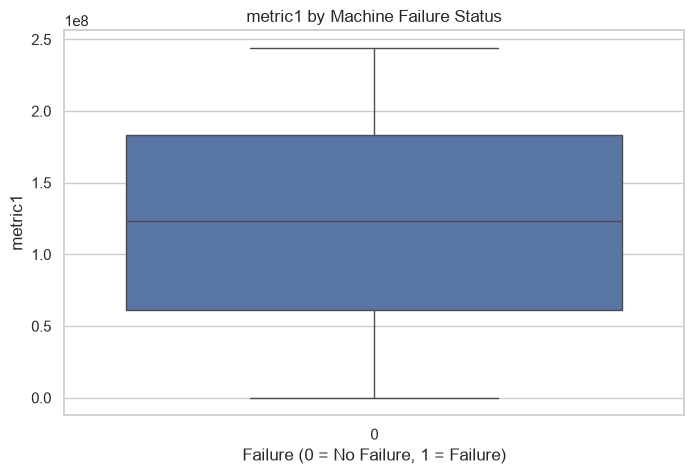

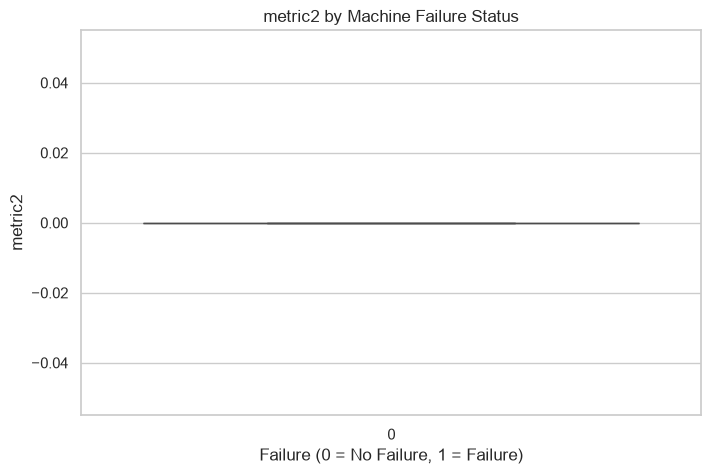

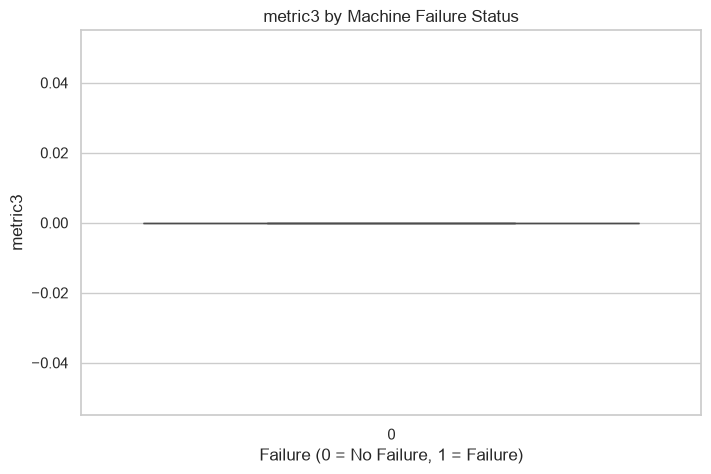

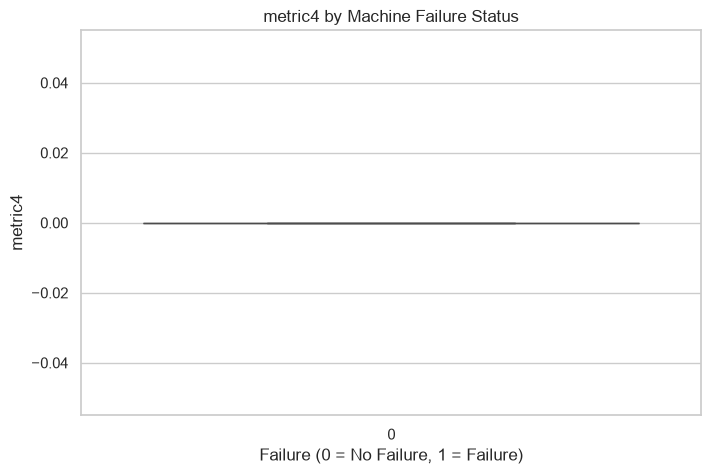

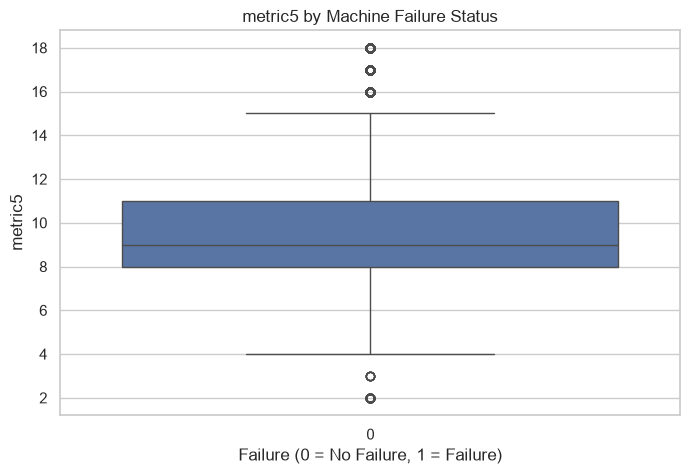

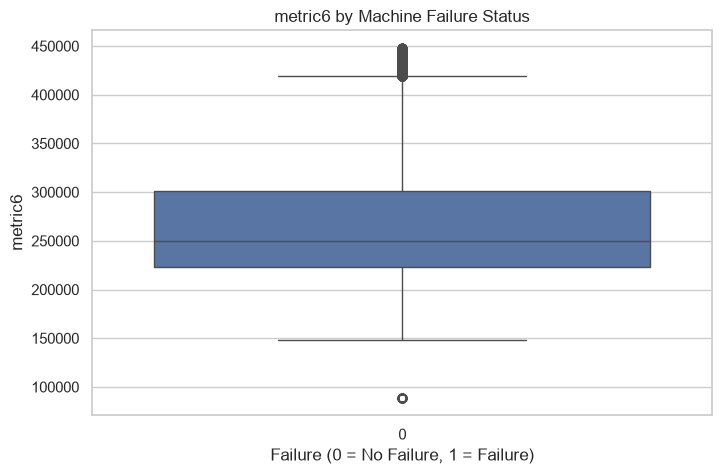

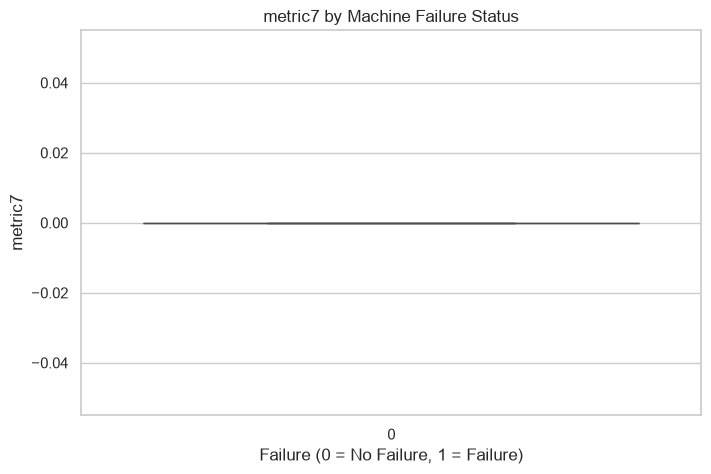

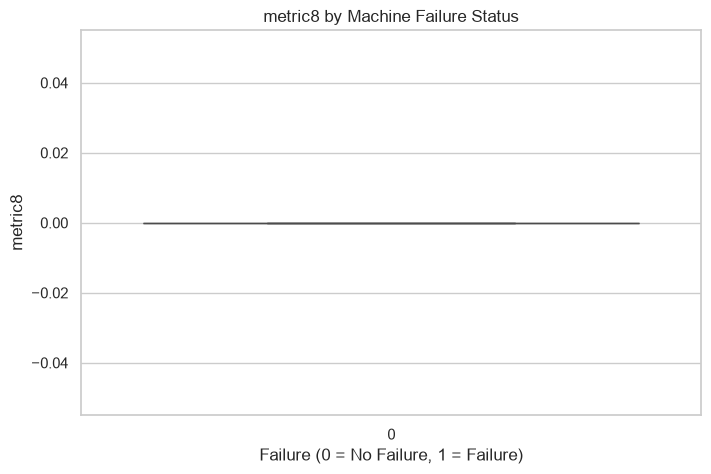

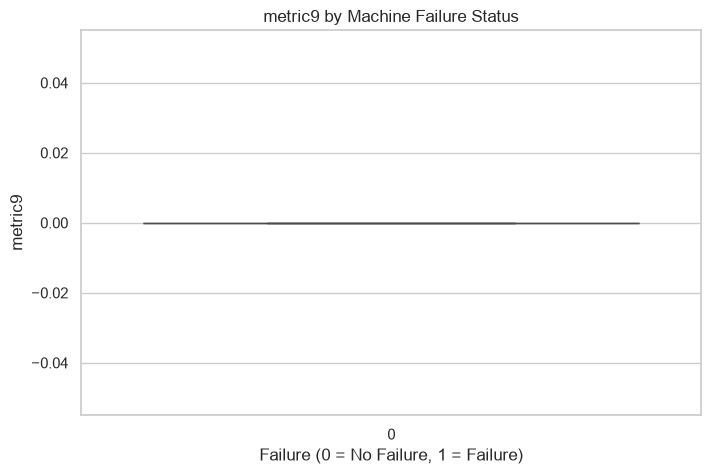

In [24]:
for col in metric_cols:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="failure",
        y=col
    )
    
    plt.title(f"{col} by Machine Failure Status")
    plt.xlabel("Failure (0 = No Failure, 1 = Failure)")
    plt.ylabel(col)
    
    plt.show()

## 15. Statistical Comparison of Metrics by Failure Status

To complement the visual analysis, descriptive statistics are calculated separately for failure and non-failure observations.

The comparison includes:

- Mean
- Median
- Standard deviation
- Minimum
- Maximum

These statistics help identify variables whose distributions differ between the two target classes.

In [25]:
failure_comparison = df.groupby("failure")[metric_cols].agg(
    ["mean", "median", "std", "min", "max"]
)

display(failure_comparison)

metric1                                           metric2  \
                 mean       median           std min        max    mean   
failure                                                                   
0        1.225493e+08  123368076.0  7.048288e+07   0  244133240     0.0   

                             ... metric8                     metric9         \
        median  std min max  ...    mean median  std min max    mean median   
failure                      ...                                              
0          0.0  0.0   0   0  ...     0.0    0.0  0.0   0   0     0.0    0.0   

                      
         std min max  
failure               
0        0.0   0   0  

[1 rows x 45 columns]

## 16. Mean Sensor Values by Failure Status

The mean value of each sensor metric is compared between failed and non-failed observations.

A difference in group means does not by itself establish causality, but it can identify variables that may contain useful predictive information.

In [26]:
mean_by_failure = df.groupby("failure")[metric_cols].mean().T

display(mean_by_failure)

failure,0
metric1,1.225493e+08
metric2,0.000000e+00
metric3,0.000000e+00
metric4,0.000000e+00
metric5,9.447022e+00
metric6,2.664616e+05
metric7,0.000000e+00
metric8,0.000000e+00
metric9,0.000000e+00


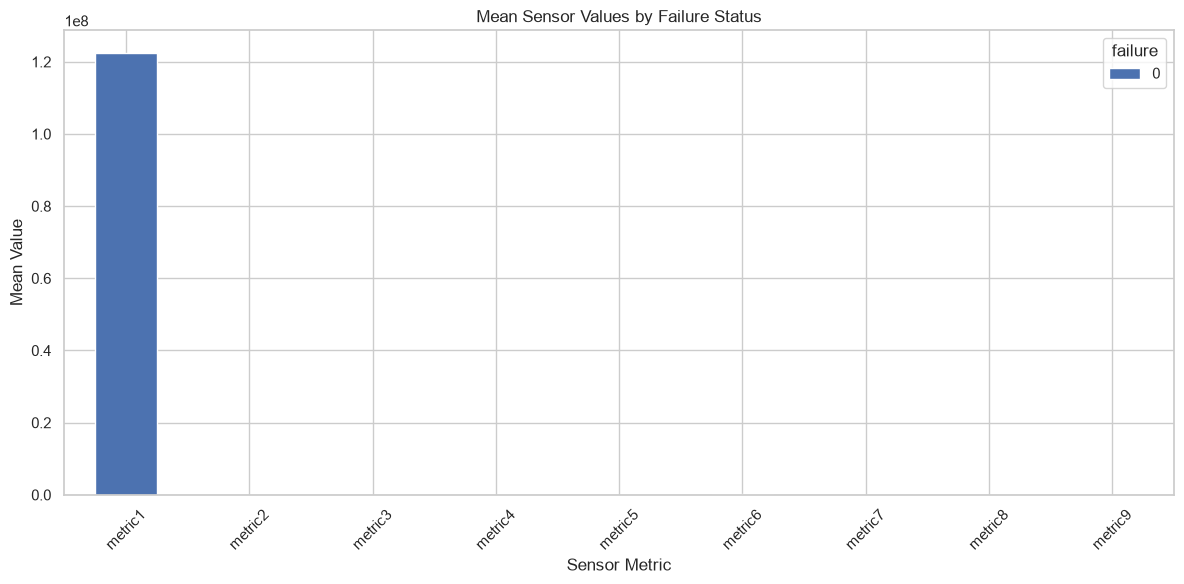

In [27]:
mean_by_failure.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Mean Sensor Values by Failure Status")
plt.xlabel("Sensor Metric")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 17. Correlation Analysis

Correlation analysis is performed to examine linear relationships among the numerical variables.

This analysis helps identify:

- Strong relationships between sensor metrics
- Potential redundancy
- Variables that may require further consideration during feature selection

Correlation does not imply causation.

In [28]:
corr_matrix = df[numeric_cols].corr()

display(corr_matrix)

,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
failure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metric1,NaN,1.000000,NaN,NaN,NaN,-0.012267,-0.007500,NaN,NaN,NaN
metric2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metric3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metric4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metric5,NaN,-0.012267,NaN,NaN,NaN,1.000000,0.160138,NaN,NaN,NaN
metric6,NaN,-0.007500,NaN,NaN,NaN,0.160138,1.000000,NaN,NaN,NaN
metric7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metric8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metric9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


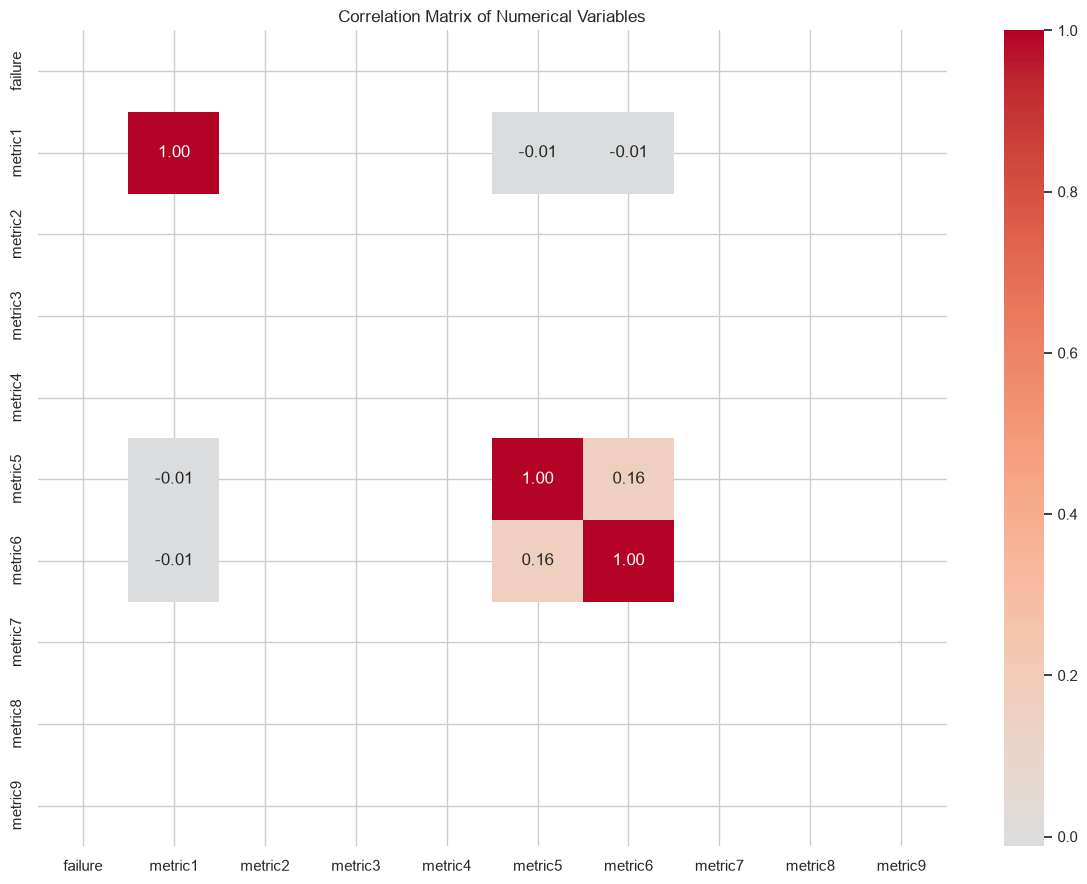

In [29]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

## 18. Device-Level Analysis

The dataset contains observations from multiple devices.

Device-level analysis is useful for understanding whether failures are evenly distributed across equipment or concentrated among particular devices.

This is also important for machine learning because repeated observations from the same device may introduce dependencies between training and testing data.

In [30]:
print("Number of unique devices:", df["device"].nunique())

Number of unique devices: 622


In [31]:
device_failure = (
    df.groupby("device")["failure"]
    .agg(["count", "sum"])
    .rename(columns={
        "count": "observations",
        "sum": "failures"
    })
)

device_failure["failure_rate"] = (
    device_failure["failures"] /
    device_failure["observations"] * 100
)

display(device_failure.sort_values("failure_rate", ascending=False).head(20))

,observations,failures,failure_rate
device,,,
S1F01E6Y,48,0,0.0
W1F0X5J5,6,0,0.0
W1F0X47B,6,0,0.0
W1F0X47W,86,0,0.0
W1F0X4F6,19,0,0.0
W1F0X4FC,21,0,0.0
W1F0X4VZ,19,0,0.0
W1F0X4ZX,84,0,0.0
W1F0X5HV,6,0,0.0


## 19. Temporal Analysis of Machine Failure

Since the dataset contains a date variable, failure observations are analyzed over time.

Temporal analysis can reveal whether failures are uniformly distributed or whether there are periods with unusually high failure activity.

This information can also guide the selection of appropriate train-test splitting strategies for time-dependent data.

In [32]:
df["year_month"] = df["date"].dt.to_period("M").astype(str)

monthly_failure = df.groupby("year_month")["failure"].agg(
    ["count", "sum"]
)

monthly_failure["failure_rate"] = (
    monthly_failure["sum"] /
    monthly_failure["count"] * 100
)

display(monthly_failure)

,count,sum,failure_rate
year_month,,,
2015-01,13528,0,0.0
2015-02,10378,0,0.0
2015-03,10494,0,0.0
2015-04,6497,0,0.0
2015-05,6062,0,0.0
2015-06,5454,0,0.0
2015-07,5349,0,0.0
2015-08,4456,0,0.0
2015-09,2429,0,0.0


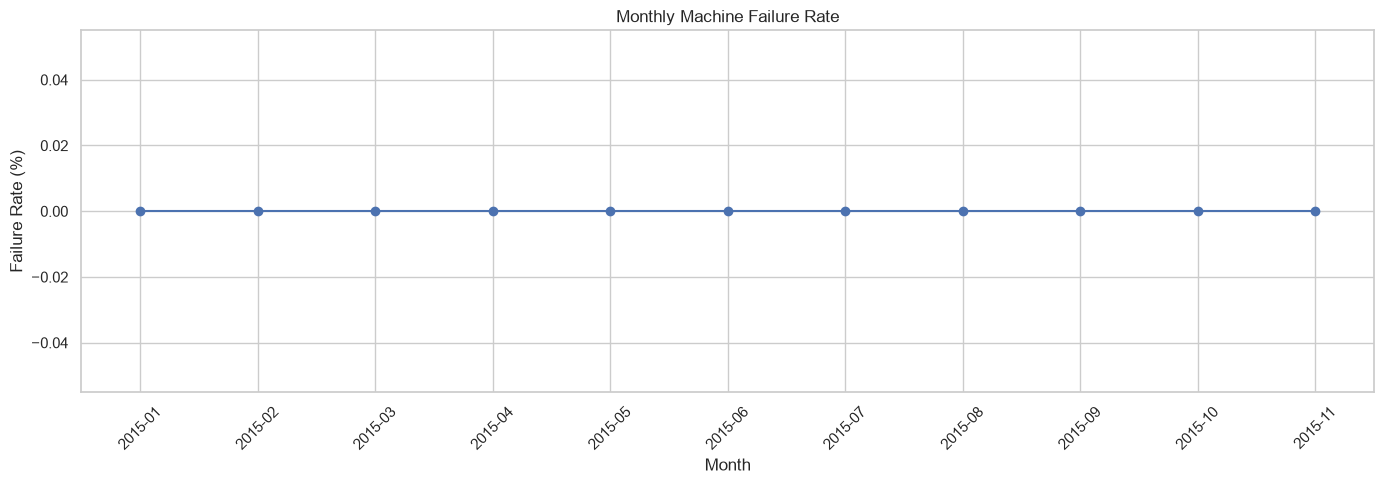

In [33]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_failure.index,
    monthly_failure["failure_rate"],
    marker="o"
)

plt.title("Monthly Machine Failure Rate")
plt.xlabel("Month")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 20. Failure Count Over Time

The number of failure events per month is visualized separately from the failure rate.

Failure count and failure rate should be distinguished because the number of observations may vary between time periods.

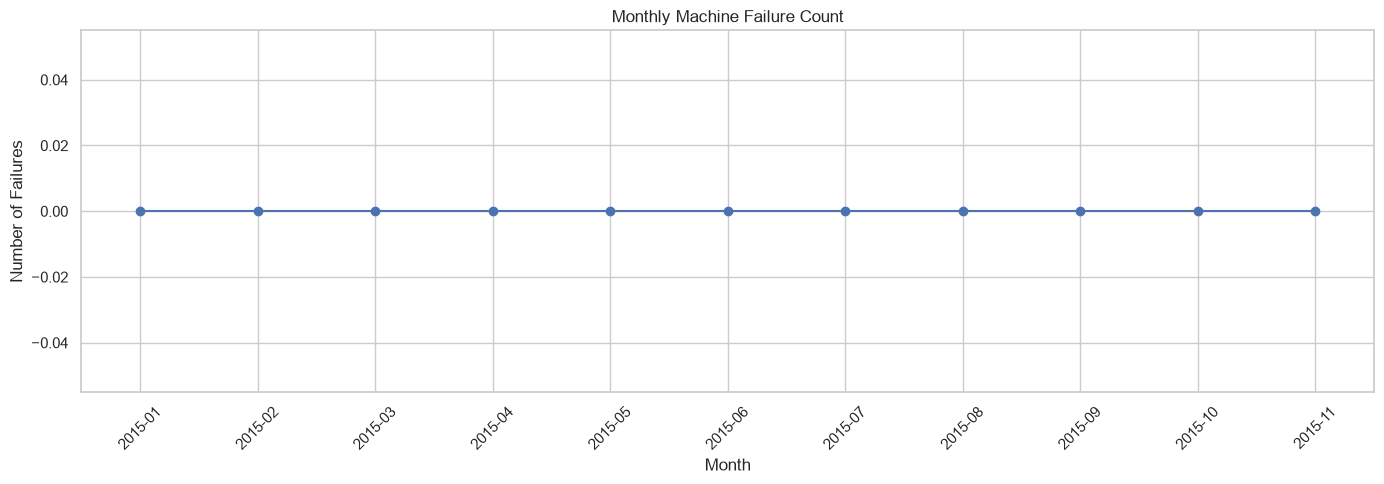

In [34]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_failure.index,
    monthly_failure["sum"],
    marker="o"
)

plt.title("Monthly Machine Failure Count")
plt.xlabel("Month")
plt.ylabel("Number of Failures")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 21. Key EDA Findings

Based on the exploratory analysis, the following findings are identified:

1. **Target distribution:**  
   The `failure` target should be examined for class imbalance. The failure class represents a much smaller proportion of observations than the non-failure class, making class imbalance an important consideration for classification.

2. **Sensor distributions:**  
   The sensor metrics exhibit different ranges and distributions. These differences should be considered during preprocessing and model development.

3. **Failure-related patterns:**  
   Comparisons between failure and non-failure observations indicate that some sensor measurements may exhibit different distributions across the two classes.

4. **Correlation:**  
   Correlation analysis identifies relationships between sensor variables. Highly correlated variables may contain overlapping information.

5. **Outliers:**  
   Several sensor measurements may contain extreme observations. These observations should be investigated rather than automatically removed because extreme operating conditions can represent legitimate industrial behavior.

6. **Temporal patterns:**  
   Failure observations can be analyzed across time to identify changes in failure frequency or failure rate.

7. **Device-level variation:**  
   Failure patterns may vary across devices. This should be considered when designing the machine learning validation strategy.

## 22. Recommendations for Machine Learning

The EDA provides several considerations for the classification stage:

- The target class distribution should be considered because failure observations are relatively rare.
- Accuracy should not be used as the only evaluation metric.
- Precision, recall, F1-score, ROC-AUC, and PR-AUC should be reported.
- Particular attention should be given to recall because missed failures can represent important operational risks.
- Potentially redundant highly correlated features should be investigated.
- Outliers should not be removed automatically without considering their operational meaning.
- The `date` variable can be transformed into useful temporal features if appropriate.
- The `device` variable requires careful consideration because repeated observations from the same device may cause data leakage if the same devices appear in both training and testing sets.
- Any preprocessing operations such as scaling and resampling should be fitted only on the training data to prevent information leakage.

# 23. Model Evaluation

## Evaluation Strategy

The trained classification models will be evaluated on a held-out test set that was not used during model training.

Because the target variable is highly imbalanced, multiple evaluation metrics will be considered.

### Evaluation Metrics

**Accuracy:** Measures the proportion of all predictions that are correct.

**Precision:** Measures how many observations predicted as failures were actually failures.

**Recall:** Measures how many actual failures were successfully detected by the model.

**F1-score:** Provides a balance between precision and recall.

**ROC-AUC:** Measures the model's ability to distinguish between failure and non-failure observations across classification thresholds.

**PR-AUC:** Provides a useful assessment for highly imbalanced classification problems by focusing on precision and recall.

### Predictive Maintenance Consideration

In predictive maintenance, false negatives can be particularly important because a false negative represents a machine that actually fails but is predicted as non-failure.

Therefore, model selection should consider the operational cost of missed failures in addition to overall predictive performance.